# Heat Equation example (d=1)

This is the simplest example provided, to get an understanding of how to build models, we will cover:

- Building a 1 dimensional model
- Factoring in boundary conditions
- Factoring differential information

---
We consider the following linear PDE problem,

\begin{equation*}
    \mathcal{L}^{\phi:=a}_xu=-a\frac{\partial^2}{\partial x^2}u(x)=f(x)
\end{equation*}

The first step in any `physgp` model is specifying this linear operator,

In [1]:
from sympy import *

L = sympify("-a*Derivative(u, x0, 2)")

For any problem, the solution function should always be denoted with `u` with the correpsonding inputs `x0,x1,..,xd` for $u:\mathbb{R}^d\rightarrow\mathbb{R}$. Next we choose the kernel for the prior for $u$, i.e. we choose the form of $k_{uu}$ in the below,

\begin{equation*}
    u \sim \mathcal{GP}(0, k_{uu}(x,x'))
\end{equation*}

This is set by creating a prior kernel object out of the kernels avalible in `physgp.priors`.

In [2]:
from physgp.priors import SquExpKernel

squexp = SquExpKernel(1)
squexp.u_func

s**2*exp(-w0*(x0 - y0)**2/2)

Now that these two have been specified we can create a PhysKerBase object, this will build all of the nessacary covariance functions needed to perform GP regression.

In [3]:
from physgp.kernels import PhysKerBase

phys_kernel_base = PhysKerBase(lin_op=L, prior_kernel=squexp)

From here we can access the individual covariance functions that have been made,

In [20]:
covariance_functions = phys_kernel_base.kernel_expression_dict

# All of the covariance functions built k_uu, k_uf, k_fu, k_ff etc.
print(list(covariance_functions.keys()))

# Looking at specifically k_ff
covariance_functions["ff"]

['uu', 'fu', 'uf', 'ff']


-a**2*s**2*w0**2*(4*w0*(x0 - y0)**2 - (w0*(x0 - y0)**2 - 1)**2 - 2)*exp(-w0*(x0 - y0)**2/2)

Next we will generate some data points $(\mathcal{X}_u, \mathcal{X}_f)$,

In [21]:
import numpy as np
from physgp.utils import obs_concat

np.random.seed(6)

n_u, n_f = 2, 2

X_u = np.random.uniform(0,1,n_u)
X_f = np.random.uniform(0,1,n_f)

data = obs_concat(X_u, X_f)
data

array([[0.        , 0.89286015],
       [0.        , 0.33197981],
       [1.        , 0.82122912],
       [1.        , 0.04169663]])

As we will be using `scikit-learn`'s GP regressor, we must only provide one input for data, hence we must label the data before being passed in. We label all of the $u$ observations with $0$ and label all of the $f$ observations with $1$ (^). This can be done simply with the provided utility function `obs_concat(`$\mathcal{X}_u, \mathcal{X}_f$`)`.

In order to create the $y$ vector, we now give a solution for our linear PDE,

\begin{equation*}
    \begin{split}
        u(x) = \sin(2\pi x)
    \end{split}\quad\quad\quad\quad
    \begin{split}
        f(x) = 4\pi^2\sin(2\pi x)
    \end{split}
\end{equation*}

Where we have set $a=1$,

In [22]:
true_f = np.vectorize(lambda x : (4*np.pi**2)*np.sin(2*np.pi*x))
true_u = np.vectorize(lambda x : np.sin(2*np.pi*x))

y = np.hstack((true_u(X_u), true_f(X_f)))
y

array([ -0.62347502,   0.87024627, -35.5902629 ,  10.2249443 ])

Let's visualise the training data in context,

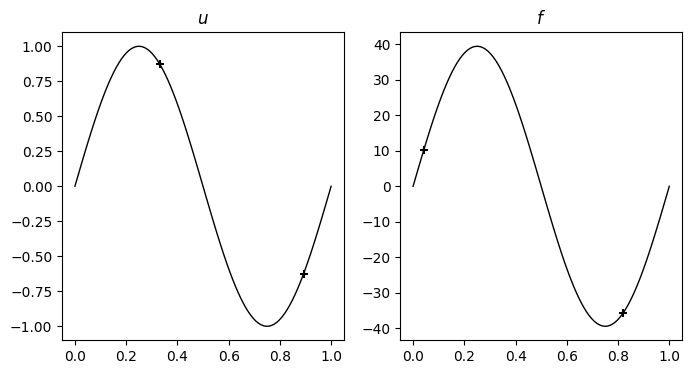

In [23]:
import matplotlib.pyplot as plt

X_plot = np.linspace(0,1,100)

fig, ax = plt.subplots(1,2, figsize=(8,4))

ax[0].plot(X_plot, true_u(X_plot), lw=1, color="black")
ax[0].scatter(X_u, true_u(X_u), marker="+", color="black")
ax[0].set_title("$u$")

ax[1].plot(X_plot, true_f(X_plot), lw=1, color="black")
ax[1].scatter(X_f, true_f(X_f), marker="+", color="black")
ax[1].set_title("$f$")

plt.show()

Now before we carry out GP regression we must first build a "translation" of our current kernel, to a kernel compatiable with `scikit-learn`, while also specifying the initial values for our hyperparameters and the range of values they can take. In order to know what we need to specify we can first run,

In [24]:
phys_kernel_base.params_to_specify

[a, s, w0]

In [25]:
from physgp.kernels import PhysKerGP

phys_kernel_gp = PhysKerGP(phys_kernel_base, 
                           param_values={"a":1, "w0":0.5, "s":1}, 
                           param_bounds={"a":(1,1), "w0":(1e-5,200), "s":(1,1)},
                           sigma=(1e-15, 1e-15))

The final specification in the above `sigma=(`$\sigma_u=$`1e-15, `$\sigma_f=$`1e-15)` specifies the noise we assume our observations to have, i.e.

\begin{equation*}
    \begin{split}
        (y_u)_i = u(x_i) + \epsilon_u,\quad\epsilon_u\sim\mathcal{N}(0,\sigma_u^2)
    \end{split}\quad\quad\quad
    \begin{split}
        (y_f)_i = f(x_i) + \epsilon_f,\quad\epsilon_f\sim\mathcal{N}(0,\sigma_f^2)
    \end{split}
\end{equation*}

Note: even in our case where we are using observations with no noise, it is advised to set $\sigma_u,\sigma_f>0$. Another point to mention, for some of the hyperparameters, we have set the bounds to the same value as our hyperparameter initial value. This is done when we want these hyperparameters to stay constant (not be optimised).

Now we have everything we need to carry out GP regression,

In [26]:
from sklearn.gaussian_process import GaussianProcessRegressor

gp = GaussianProcessRegressor(kernel=phys_kernel_gp,
                              random_state=2,
                              alpha=1e-15,
                              n_restarts_optimizer=2)

gp.fit(data, y)

c:\Users\marku\physgp\physgp\.venv\Lib\site-packages\sklearn\gaussian_process\kernels.py:440: ConvergenceWarning: The optimal value found for dimension 0 of parameter s is close to the specified lower bound 1. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(


,"kernel kernel: kernel instance, default=NoneThe kernel specifying the covariance function of the GP. If None ispassed, the kernel ``ConstantKernel(1.0, constant_value_bounds=""fixed"")* RBF(1.0, length_scale_bounds=""fixed"")`` is used as default. Note thatthe kernel hyperparameters are optimized during fitting unless thebounds are marked as ""fixed"".","PhysKerGP(1, 0.5, 1)"
,"alpha alpha: float or ndarray of shape (n_samples,), default=1e-10Value added to the diagonal of the kernel matrix during fitting.This can prevent a potential numerical issue during fitting, byensuring that the calculated values form a positive definite matrix.It can also be interpreted as the variance of additional Gaussianmeasurement noise on the training observations. Note that this isdifferent from using a `WhiteKernel`. If an array is passed, it musthave the same number of entries as the data used for fitting and isused as datapoint-dependent noise level. Allowing to specify thenoise level directly as a parameter is mainly for convenience andfor consistency with :class:`~sklearn.linear_model.Ridge`.For an example illustrating how the alpha parameter controlsthe noise variance in Gaussian Process Regression, see:ref:`sphx_glr_auto_examples_gaussian_process_plot_gpr_noisy_targets.py`.",1e-15
,"optimizer optimizer: ""fmin_l_bfgs_b"", callable or None, default=""fmin_l_bfgs_b""Can either be one of the internally supported optimizers for optimizingthe kernel's parameters, specified by a string, or an externallydefined optimizer passed as a callable. If a callable is passed, itmust have the signature:: def optimizer(obj_func, initial_theta, bounds): # * 'obj_func': the objective function to be minimized, which # takes the hyperparameters theta as a parameter and an # optional flag eval_gradient, which determines if the # gradient is returned additionally to the function value # * 'initial_theta': the initial value for theta, which can be # used by local optimizers # * 'bounds': the bounds on the values of theta .... # Returned are the best found hyperparameters theta and # the corresponding value of the target function. return theta_opt, func_minPer default, the L-BFGS-B algorithm from `scipy.optimize.minimize`is used. If None is passed, the kernel's parameters are kept fixed.Available internal optimizers are: `{'fmin_l_bfgs_b'}`.",'fmin_l_bfgs_b'
,"n_restarts_optimizer n_restarts_optimizer: int, default=0The number of restarts of the optimizer for finding the kernel'sparameters which maximize the log-marginal likelihood. The first runof the optimizer is performed from the kernel's initial parameters,the remaining ones (if any) from thetas sampled log-uniform randomlyfrom the space of allowed theta-values. If greater than 0, all boundsmust be finite. Note that `n_restarts_optimizer == 0` implies that onerun is performed.",2
,"normalize_y normalize_y: bool, default=FalseWhether or not to normalize the target values `y` by removing the meanand scaling to unit-variance. This is recommended for cases wherezero-mean, unit-variance priors are used. Note that, in thisimplementation, the normalisation is reversed before the GP predictionsare reported... versionchanged:: 0.23",False
,"copy_X_train copy_X_train: bool, default=TrueIf True, a persistent copy of the training data is stored in theobject. Otherwise, just a reference to the training data is stored,which might cause predictions to change if the data is modifiedexternally.",True
,"n_targets n_targets: int, default=NoneThe number of dimensions of the target values. Used to decide the numberof outputs when sampling from the prior distributions (i.e. calling:meth:`sample_y` before :meth:`fit`). This parameter is ignored once:meth:`fit` has been called... versionadded:: 1.3",None
,"random_state random_state: int, RandomState instance or None, default=NoneDetermines random number generation used to initialize the centers.Pass an int for reproducible results across multiple function calls.See :term:`Glossary 

Note: in the above we should have,

- `alpha` close to $0$ : as this is effectively a noise parameter, and we have already added noise. 
- `n_restart_optimizer` : should be set $>1$ if we want to optimize any hyperparameters, controls how many random initializations of the optimization problem are carried out.

Now we can produce our posterior/predicted mean fit, along with the uncertainty. 

In [27]:
X = np.linspace(0,1,50)

u_mean_prediction, u_covariance_matrix = gp.predict(obs_concat(X_u=X), return_cov=True)
f_mean_prediction, f_covariance_matrix = gp.predict(obs_concat(X_f=X), return_cov=True)

We advise using `return_cov` instead of `return_std` as it is more stable for this use case.

We can then visualise this fit,

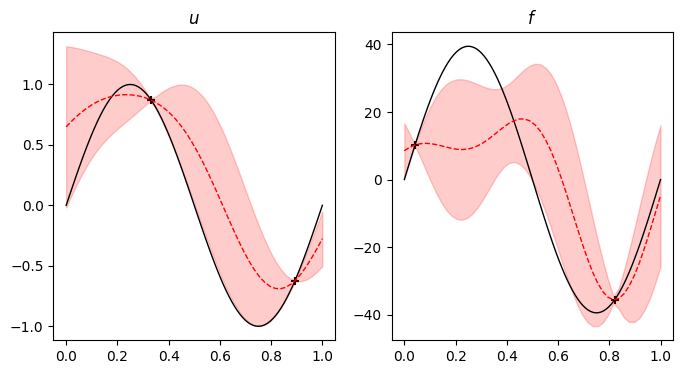

In [29]:
import matplotlib.pyplot as plt

X_plot = np.linspace(0,1,100)

fig, ax = plt.subplots(1,2, figsize=(8,4))

ax[0].plot(X_plot, true_u(X_plot), lw=1, color="black")
ax[0].scatter(X_u, true_u(X_u), marker="+", color="black")
ax[0].set_title("$u$")

# Plotting posterior GP (u)
ax[0].plot(X, u_mean_prediction, color="red", linestyle="--", lw=1)
u_std = np.sqrt(np.diagonal(u_covariance_matrix))
ax[0].fill_between(X, u_mean_prediction-u_std, u_mean_prediction+u_std, color="red", alpha=0.2)


ax[1].plot(X_plot, true_f(X_plot), lw=1, color="black")
ax[1].scatter(X_f, true_f(X_f), marker="+", color="black")
ax[1].set_title("$f$")

# Plotting posterior GP (f)
ax[1].plot(X, f_mean_prediction, color="red", linestyle="--", lw=1)
f_std = np.sqrt(np.diagonal(f_covariance_matrix))
ax[1].fill_between(X, f_mean_prediction-f_std, f_mean_prediction+f_std, color="red", alpha=0.2)


plt.show()

## Factoring in boundary conditions

### Dirichlet conditions

Now, in practice, linear PDE problems have boundary conditions, we will now explain how to implement boundary conditions (BCs) into the above model. Consider Dirichlet boundary conditions for our linear PDE problem,

\begin{equation*}
    u(x=0)=0\quad,\quad u(x=1)=0
\end{equation*}

Let us rewrite this in the form of an operator acting on $u$ and some condition for the values of $x$ that lie on the boundary.

\begin{equation*}
    \mathcal{B}[u]=u|_{\partial\mathcal{D}}=0\quad\&\quad\partial\mathcal{D}:=\{0,1\}
\end{equation*}

We can then specify the BCs in this form for our model,

In [30]:
boundary_operators = [sympify("u")]
boundary_conditions = [lambda x0 : x0 in [0,1]]

We specify a list of boundary operators (all `sympy` expressions with same requirements as those mentioned for the linear operator), and the corresponding list of conditions (a list of lambda functions that take the point $x$ as input and return True or False if $x$ is on the respective boundary or not). These two lists can then be added to the instansiation of the PhysKerBase object.

In [33]:
phys_kernel_base_bc_d = PhysKerBase(lin_op=L, 
                               prior_kernel=squexp, 
                               boundary_operators=boundary_operators, 
                               boundary_conditions=boundary_conditions)

In [34]:
list(phys_kernel_base_bc_d.kernel_expression_dict.keys())

['uu', 'fu', 'uf', 'ff', 'b0u', 'ub0', 'b0f', 'fb0', 'b0b0']

Then we continue in the same way as the above,

In [ ]:
phys_kernel_gp_bc_d = PhysKerGP(phys_kernel_base_bc_d, 
                                param_values={"a":1, "w0":0.5, "s":1}, 
                                param_bounds={"a":(1,1), "w0":(1e-5,200), "s":(1,1)},
                                sigma=(1e-15, 1e-15))

There is only one main difference now, we must specify the correct $y_i$ for the instances on the boundary, it doesn't impact in the case of dirichlet too much although as we consider derivative information (Neumann BCs) it will be important. 

In [43]:
X_u_boundary = np.array([0,1])
X_u_bc_d = np.hstack((X_u, X_u_boundary))
y_bc_d = np.hstack((true_u(X_u), true_u(X_u_boundary), true_f(X_f)))
print(X_u_bc_d, X_f)
print(y_bc_d)

[0.89286015 0.33197981 0.         1.        ] [0.82122912 0.04169663]
[-6.23475022e-01  8.70246268e-01  0.00000000e+00 -2.44929360e-16
 -3.55902629e+01  1.02249443e+01]


Now we can fit our model with BCs accounted for, and produce a prediction,

In [ ]:
data_bc_d = obs_concat(X_u_bc_d, X_f)

gp_bc_d = GaussianProcessRegressor(kernel=phys_kernel_gp_bc_d,
                                    random_state=2,
                                    alpha=1e-15,
                                    n_restarts_optimizer=2)

gp_bc_d.fit(data_bc_d, y_bc_d)

c:\Users\marku\physgp\physgp\.venv\Lib\site-packages\sklearn\gaussian_process\kernels.py:440: ConvergenceWarning: The optimal value found for dimension 0 of parameter s is close to the specified lower bound 1. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(


,"kernel kernel: kernel instance, default=NoneThe kernel specifying the covariance function of the GP. If None ispassed, the kernel ``ConstantKernel(1.0, constant_value_bounds=""fixed"")* RBF(1.0, length_scale_bounds=""fixed"")`` is used as default. Note thatthe kernel hyperparameters are optimized during fitting unless thebounds are marked as ""fixed"".","PhysKerGP(1, 0.5, 1)"
,"alpha alpha: float or ndarray of shape (n_samples,), default=1e-10Value added to the diagonal of the kernel matrix during fitting.This can prevent a potential numerical issue during fitting, byensuring that the calculated values form a positive definite matrix.It can also be interpreted as the variance of additional Gaussianmeasurement noise on the training observations. Note that this isdifferent from using a `WhiteKernel`. If an array is passed, it musthave the same number of entries as the data used for fitting and isused as datapoint-dependent noise level. Allowing to specify thenoise level directly as a parameter is mainly for convenience andfor consistency with :class:`~sklearn.linear_model.Ridge`.For an example illustrating how the alpha parameter controlsthe noise variance in Gaussian Process Regression, see:ref:`sphx_glr_auto_examples_gaussian_process_plot_gpr_noisy_targets.py`.",1e-15
,"optimizer optimizer: ""fmin_l_bfgs_b"", callable or None, default=""fmin_l_bfgs_b""Can either be one of the internally supported optimizers for optimizingthe kernel's parameters, specified by a string, or an externallydefined optimizer passed as a callable. If a callable is passed, itmust have the signature:: def optimizer(obj_func, initial_theta, bounds): # * 'obj_func': the objective function to be minimized, which # takes the hyperparameters theta as a parameter and an # optional flag eval_gradient, which determines if the # gradient is returned additionally to the function value # * 'initial_theta': the initial value for theta, which can be # used by local optimizers # * 'bounds': the bounds on the values of theta .... # Returned are the best found hyperparameters theta and # the corresponding value of the target function. return theta_opt, func_minPer default, the L-BFGS-B algorithm from `scipy.optimize.minimize`is used. If None is passed, the kernel's parameters are kept fixed.Available internal optimizers are: `{'fmin_l_bfgs_b'}`.",'fmin_l_bfgs_b'
,"n_restarts_optimizer n_restarts_optimizer: int, default=0The number of restarts of the optimizer for finding the kernel'sparameters which maximize the log-marginal likelihood. The first runof the optimizer is performed from the kernel's initial parameters,the remaining ones (if any) from thetas sampled log-uniform randomlyfrom the space of allowed theta-values. If greater than 0, all boundsmust be finite. Note that `n_restarts_optimizer == 0` implies that onerun is performed.",2
,"normalize_y normalize_y: bool, default=FalseWhether or not to normalize the target values `y` by removing the meanand scaling to unit-variance. This is recommended for cases wherezero-mean, unit-variance priors are used. Note that, in thisimplementation, the normalisation is reversed before the GP predictionsare reported... versionchanged:: 0.23",False
,"copy_X_train copy_X_train: bool, default=TrueIf True, a persistent copy of the training data is stored in theobject. Otherwise, just a reference to the training data is stored,which might cause predictions to change if the data is modifiedexternally.",True
,"n_targets n_targets: int, default=NoneThe number of dimensions of the target values. Used to decide the numberof outputs when sampling from the prior distributions (i.e. calling:meth:`sample_y` before :meth:`fit`). This parameter is ignored once:meth:`fit` has been called... versionadded:: 1.3",None
,"random_state random_state: int, RandomState instance or None, default=NoneDetermines random number generation used to initialize the centers.Pass an int for reproducible results across multiple function calls.See :term:`Glossary 

In [47]:
X = np.linspace(0,1,50)

u_mean_prediction, u_covariance_matrix = gp_bc_d.predict(obs_concat(X_u=X), return_cov=True)
f_mean_prediction, f_covariance_matrix = gp_bc_d.predict(obs_concat(X_f=X), return_cov=True)

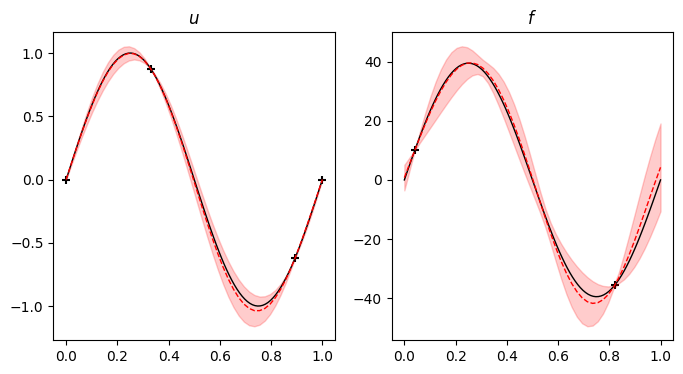

In [48]:
import matplotlib.pyplot as plt

X_plot = np.linspace(0,1,100)

fig, ax = plt.subplots(1,2, figsize=(8,4))

ax[0].plot(X_plot, true_u(X_plot), lw=1, color="black")
ax[0].scatter(X_u_bc_d, true_u(X_u_bc_d), marker="+", color="black") # Plotting points + boundary points
ax[0].set_title("$u$")

# Plotting posterior GP (u)
ax[0].plot(X, u_mean_prediction, color="red", linestyle="--", lw=1)
u_std = np.sqrt(np.diagonal(u_covariance_matrix))
ax[0].fill_between(X, u_mean_prediction-u_std, u_mean_prediction+u_std, color="red", alpha=0.2)


ax[1].plot(X_plot, true_f(X_plot), lw=1, color="black")
ax[1].scatter(X_f, true_f(X_f), marker="+", color="black")
ax[1].set_title("$f$")

# Plotting posterior GP (f)
ax[1].plot(X, f_mean_prediction, color="red", linestyle="--", lw=1)
f_std = np.sqrt(np.diagonal(f_covariance_matrix))
ax[1].fill_between(X, f_mean_prediction-f_std, f_mean_prediction+f_std, color="red", alpha=0.2)


plt.show()

### Neumann conditions

To help reiterate the above, let us now consider Neumann BCs,

\begin{equation*}
    \frac{\partial}{\partial x}u(x=0) = 2\pi \quad, \quad \frac{\partial}{\partial x}u(x=1) = 2\pi
\end{equation*}

Rewriting the above,

\begin{equation*}
    \mathcal{B}[u]=\frac{\partial}{\partial x}u|_{\partial\mathcal{D}}=2\pi\quad\&\quad\partial\mathcal{D}:=\{0,1\}
\end{equation*}

This can then be implemented as,

In [56]:
boundary_operators_neumann = [sympify("Derivative(u, x0, 1)")]
boundary_conditions_neumann = [lambda x0 : x0 in [0,1]]

phys_kernel_base_bc_n = PhysKerBase(lin_op=L, 
                               prior_kernel=squexp, 
                               boundary_operators=boundary_operators_neumann, 
                               boundary_conditions=boundary_conditions_neumann)

phys_kernel_gp_bc_n = PhysKerGP(phys_kernel_base_bc_n, 
                                param_values={"a":1, "w0":0.5, "s":1}, 
                                param_bounds={"a":(1,1), "w0":(1e-5,200), "s":(1,1)},
                                sigma=(1e-15, 1e-15))

X will be the same as in the Dirichlet case, but now $y$ must specify the derivative at these points (not the actual value for $u$),

In [57]:
y_bc_n = np.hstack((true_u(X_u), np.array([2*np.pi, 2*np.pi]), true_f(X_f)))

print(X_u_bc_d, X_f)
print(y_bc_n)

[0.89286015 0.33197981 0.         1.        ] [0.82122912 0.04169663]
[ -0.62347502   0.87024627   6.28318531   6.28318531 -35.5902629
  10.2249443 ]


In [58]:
gp_bc_n = GaussianProcessRegressor(kernel=phys_kernel_gp_bc_n,
                                    random_state=2,
                                    alpha=1e-15,
                                    n_restarts_optimizer=2)

gp_bc_n.fit(data_bc_d, y_bc_n)

c:\Users\marku\physgp\physgp\.venv\Lib\site-packages\sklearn\gaussian_process\kernels.py:440: ConvergenceWarning: The optimal value found for dimension 0 of parameter s is close to the specified lower bound 1. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(


,"kernel kernel: kernel instance, default=NoneThe kernel specifying the covariance function of the GP. If None ispassed, the kernel ``ConstantKernel(1.0, constant_value_bounds=""fixed"")* RBF(1.0, length_scale_bounds=""fixed"")`` is used as default. Note thatthe kernel hyperparameters are optimized during fitting unless thebounds are marked as ""fixed"".","PhysKerGP(1, 0.5, 1)"
,"alpha alpha: float or ndarray of shape (n_samples,), default=1e-10Value added to the diagonal of the kernel matrix during fitting.This can prevent a potential numerical issue during fitting, byensuring that the calculated values form a positive definite matrix.It can also be interpreted as the variance of additional Gaussianmeasurement noise on the training observations. Note that this isdifferent from using a `WhiteKernel`. If an array is passed, it musthave the same number of entries as the data used for fitting and isused as datapoint-dependent noise level. Allowing to specify thenoise level directly as a parameter is mainly for convenience andfor consistency with :class:`~sklearn.linear_model.Ridge`.For an example illustrating how the alpha parameter controlsthe noise variance in Gaussian Process Regression, see:ref:`sphx_glr_auto_examples_gaussian_process_plot_gpr_noisy_targets.py`.",1e-15
,"optimizer optimizer: ""fmin_l_bfgs_b"", callable or None, default=""fmin_l_bfgs_b""Can either be one of the internally supported optimizers for optimizingthe kernel's parameters, specified by a string, or an externallydefined optimizer passed as a callable. If a callable is passed, itmust have the signature:: def optimizer(obj_func, initial_theta, bounds): # * 'obj_func': the objective function to be minimized, which # takes the hyperparameters theta as a parameter and an # optional flag eval_gradient, which determines if the # gradient is returned additionally to the function value # * 'initial_theta': the initial value for theta, which can be # used by local optimizers # * 'bounds': the bounds on the values of theta .... # Returned are the best found hyperparameters theta and # the corresponding value of the target function. return theta_opt, func_minPer default, the L-BFGS-B algorithm from `scipy.optimize.minimize`is used. If None is passed, the kernel's parameters are kept fixed.Available internal optimizers are: `{'fmin_l_bfgs_b'}`.",'fmin_l_bfgs_b'
,"n_restarts_optimizer n_restarts_optimizer: int, default=0The number of restarts of the optimizer for finding the kernel'sparameters which maximize the log-marginal likelihood. The first runof the optimizer is performed from the kernel's initial parameters,the remaining ones (if any) from thetas sampled log-uniform randomlyfrom the space of allowed theta-values. If greater than 0, all boundsmust be finite. Note that `n_restarts_optimizer == 0` implies that onerun is performed.",2
,"normalize_y normalize_y: bool, default=FalseWhether or not to normalize the target values `y` by removing the meanand scaling to unit-variance. This is recommended for cases wherezero-mean, unit-variance priors are used. Note that, in thisimplementation, the normalisation is reversed before the GP predictionsare reported... versionchanged:: 0.23",False
,"copy_X_train copy_X_train: bool, default=TrueIf True, a persistent copy of the training data is stored in theobject. Otherwise, just a reference to the training data is stored,which might cause predictions to change if the data is modifiedexternally.",True
,"n_targets n_targets: int, default=NoneThe number of dimensions of the target values. Used to decide the numberof outputs when sampling from the prior distributions (i.e. calling:meth:`sample_y` before :meth:`fit`). This parameter is ignored once:meth:`fit` has been called... versionadded:: 1.3",None
,"random_state random_state: int, RandomState instance or None, default=NoneDetermines random number generation used to initialize the centers.Pass an int for reproducible results across multiple function calls.See :term:`Glossary 

In [60]:
X = np.linspace(0,1,50)

u_mean_prediction, u_covariance_matrix = gp_bc_n.predict(obs_concat(X_u=X), return_cov=True)
f_mean_prediction, f_covariance_matrix = gp_bc_n.predict(obs_concat(X_f=X), return_cov=True)

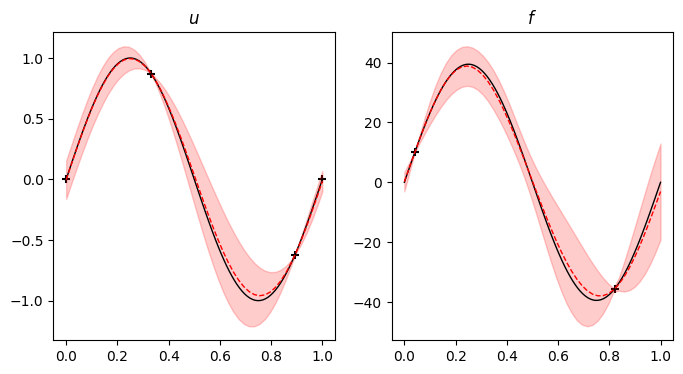

In [61]:
import matplotlib.pyplot as plt

X_plot = np.linspace(0,1,100)

fig, ax = plt.subplots(1,2, figsize=(8,4))

ax[0].plot(X_plot, true_u(X_plot), lw=1, color="black")
ax[0].scatter(X_u_bc_d, true_u(X_u_bc_d), marker="+", color="black") # Plotting points + boundary points
ax[0].set_title("$u$")

# Plotting posterior GP (u)
ax[0].plot(X, u_mean_prediction, color="red", linestyle="--", lw=1)
u_std = np.sqrt(np.diagonal(u_covariance_matrix))
ax[0].fill_between(X, u_mean_prediction-u_std, u_mean_prediction+u_std, color="red", alpha=0.2)


ax[1].plot(X_plot, true_f(X_plot), lw=1, color="black")
ax[1].scatter(X_f, true_f(X_f), marker="+", color="black")
ax[1].set_title("$f$")

# Plotting posterior GP (f)
ax[1].plot(X, f_mean_prediction, color="red", linestyle="--", lw=1)
f_std = np.sqrt(np.diagonal(f_covariance_matrix))
ax[1].fill_between(X, f_mean_prediction-f_std, f_mean_prediction+f_std, color="red", alpha=0.2)


plt.show()

### General dervative information

Notice, because of how we factor in boundary conditions in the above we can factor in any linear derivative information about $u$. For instance consider the points $x=3/4$ in the above, this is the location of the minimum of $u$, hence, 

\begin{equation*}
    \frac{\partial}{\partial x}u(x=3/4)=0 \quad \& \quad \frac{\partial^2}{\partial x^2}u(x=3/4)>0
\end{equation*}

We can then rewrite this as,

\begin{equation*}
    \mathcal{B}_1[u]=\frac{\partial}{\partial x}u|_{\partial\mathcal{D}}=0\quad\&\quad\partial\mathcal{D}:=\{3/4\}
\end{equation*}

\begin{equation*}
    \mathcal{B}_2[u]=b\frac{\partial^2}{\partial x^2}u|_{\partial\mathcal{D}}=1\quad\&\quad\partial\mathcal{D}:=\{3/4\}\quad :\quad b\in[0,\infty)
\end{equation*}

We have introduced this new hyperparameter $b$ to overcome the inequality, it then joins the set of hyperparameters we want to specify and optimise,

In [88]:
boundary_operators_Mm = [sympify("Derivative(u, x0, 1)"), sympify("b*Derivative(u, x0, 2)")]
 # We are still enforcing the Neumann BCs    \/     \/
boundary_conditions_Mm = [lambda x0 : x0 in [0,0.75,1], lambda x0 : x0 in [0.75]]

In [89]:
phys_kernel_base_Mm = PhysKerBase(lin_op=L, 
                               prior_kernel=squexp, 
                               boundary_operators=boundary_operators_Mm, 
                               boundary_conditions=boundary_conditions_Mm)

phys_kernel_gp_Mm = PhysKerGP(phys_kernel_base_Mm, 
                                param_values={"a":1, "w0":0.5, "s":1, "b":1}, # Adding the b parameter value
                                param_bounds={"a":(1,1), "w0":(1e-5,200), "s":(1,1), "b":(0,200)},
                                sigma=(1e-15, 1e-15))

As we have two boundary operators for 1 point, we must pass in two instances of $x=0.75$, as our model will assume the first boundary operator is used for the first instance and the second for the second instance. This means if you want to priortise certain differential/boundary operators over others they should appear towards the front of the list. 

In [90]:
X_u_Mm_value = np.array([0.75, 0.75])
X_u_Mm = np.hstack((X_u_bc_d, X_u_Mm_value))

# As we have custom derivative information we must ensure the right y values are in the right place.
y_values_for_Mm = np.array([0, 1])
y_Mm = np.hstack((true_u(X_u_bc_d), y_values_for_Mm, true_f(X_f))) 

data_Mm = obs_concat(X_u_Mm, X_f)

print(X_u_Mm, X_f)
print(y_Mm)

[0.89286015 0.33197981 0.         1.         0.75       0.75      ] [0.82122912 0.04169663]
[-6.23475022e-01  8.70246268e-01  0.00000000e+00 -2.44929360e-16
  0.00000000e+00  1.00000000e+00 -3.55902629e+01  1.02249443e+01]


In [94]:
gp_Mm = GaussianProcessRegressor(kernel=phys_kernel_gp_Mm,
                                    random_state=2,
                                    alpha=1e-15,
                                    n_restarts_optimizer=2)

gp_Mm.fit(data_Mm, y_Mm)

c:\Users\marku\physgp\physgp\.venv\Lib\site-packages\sklearn\gaussian_process\kernels.py:440: ConvergenceWarning: The optimal value found for dimension 0 of parameter b is close to the specified lower bound 0. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(


,"kernel kernel: kernel instance, default=NoneThe kernel specifying the covariance function of the GP. If None ispassed, the kernel ``ConstantKernel(1.0, constant_value_bounds=""fixed"")* RBF(1.0, length_scale_bounds=""fixed"")`` is used as default. Note thatthe kernel hyperparameters are optimized during fitting unless thebounds are marked as ""fixed"".","PhysKerGP(1, 0.5, 1, 1)"
,"alpha alpha: float or ndarray of shape (n_samples,), default=1e-10Value added to the diagonal of the kernel matrix during fitting.This can prevent a potential numerical issue during fitting, byensuring that the calculated values form a positive definite matrix.It can also be interpreted as the variance of additional Gaussianmeasurement noise on the training observations. Note that this isdifferent from using a `WhiteKernel`. If an array is passed, it musthave the same number of entries as the data used for fitting and isused as datapoint-dependent noise level. Allowing to specify thenoise level directly as a parameter is mainly for convenience andfor consistency with :class:`~sklearn.linear_model.Ridge`.For an example illustrating how the alpha parameter controlsthe noise variance in Gaussian Process Regression, see:ref:`sphx_glr_auto_examples_gaussian_process_plot_gpr_noisy_targets.py`.",1e-15
,"optimizer optimizer: ""fmin_l_bfgs_b"", callable or None, default=""fmin_l_bfgs_b""Can either be one of the internally supported optimizers for optimizingthe kernel's parameters, specified by a string, or an externallydefined optimizer passed as a callable. If a callable is passed, itmust have the signature:: def optimizer(obj_func, initial_theta, bounds): # * 'obj_func': the objective function to be minimized, which # takes the hyperparameters theta as a parameter and an # optional flag eval_gradient, which determines if the # gradient is returned additionally to the function value # * 'initial_theta': the initial value for theta, which can be # used by local optimizers # * 'bounds': the bounds on the values of theta .... # Returned are the best found hyperparameters theta and # the corresponding value of the target function. return theta_opt, func_minPer default, the L-BFGS-B algorithm from `scipy.optimize.minimize`is used. If None is passed, the kernel's parameters are kept fixed.Available internal optimizers are: `{'fmin_l_bfgs_b'}`.",'fmin_l_bfgs_b'
,"n_restarts_optimizer n_restarts_optimizer: int, default=0The number of restarts of the optimizer for finding the kernel'sparameters which maximize the log-marginal likelihood. The first runof the optimizer is performed from the kernel's initial parameters,the remaining ones (if any) from thetas sampled log-uniform randomlyfrom the space of allowed theta-values. If greater than 0, all boundsmust be finite. Note that `n_restarts_optimizer == 0` implies that onerun is performed.",2
,"normalize_y normalize_y: bool, default=FalseWhether or not to normalize the target values `y` by removing the meanand scaling to unit-variance. This is recommended for cases wherezero-mean, unit-variance priors are used. Note that, in thisimplementation, the normalisation is reversed before the GP predictionsare reported... versionchanged:: 0.23",False
,"copy_X_train copy_X_train: bool, default=TrueIf True, a persistent copy of the training data is stored in theobject. Otherwise, just a reference to the training data is stored,which might cause predictions to change if the data is modifiedexternally.",True
,"n_targets n_targets: int, default=NoneThe number of dimensions of the target values. Used to decide the numberof outputs when sampling from the prior distributions (i.e. calling:meth:`sample_y` before :meth:`fit`). This parameter is ignored once:meth:`fit` has been called... versionadded:: 1.3",None
,"random_state random_state: int, RandomState instance or None, default=NoneDetermines random number generation used to initialize the centers.Pass an int for reproducible results across multiple function calls.See :term:`Glossa

In [95]:
gp_Mm.kernel_.param_values

{'a': np.float64(1.0),
 'w0': np.float64(21.25035846632422),
 's': np.float64(1.0),
 'b': np.float64(0.014776186756953575)}

In [96]:
X = np.linspace(0,1,50)

u_mean_prediction, u_covariance_matrix = gp_Mm.predict(obs_concat(X_u=X), return_cov=True)
f_mean_prediction, f_covariance_matrix = gp_Mm.predict(obs_concat(X_f=X), return_cov=True)

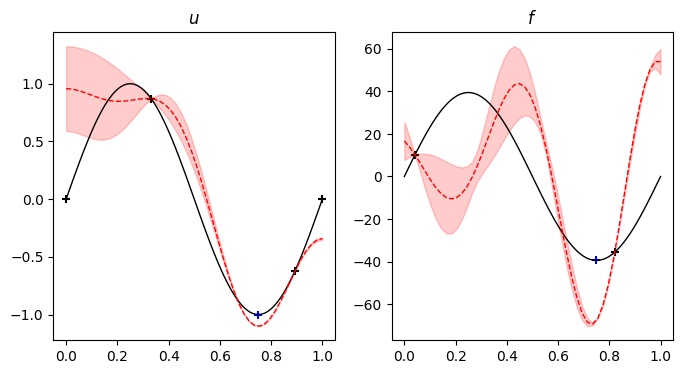

In [99]:
import matplotlib.pyplot as plt

X_plot = np.linspace(0,1,100)

fig, ax = plt.subplots(1,2, figsize=(8,4))

ax[0].plot(X_plot, true_u(X_plot), lw=1, color="black")
ax[0].scatter(X_u_bc_d, true_u(X_u_bc_d), marker="+", color="black") # Plotting points + boundary points
ax[0].scatter(0.75, true_u(0.75), marker="+", color="blue") # Minima point
ax[0].set_title("$u$")

# Plotting posterior GP (u)
ax[0].plot(X, u_mean_prediction, color="red", linestyle="--", lw=1)
u_std = np.sqrt(np.diagonal(u_covariance_matrix))
ax[0].fill_between(X, u_mean_prediction-u_std, u_mean_prediction+u_std, color="red", alpha=0.2)


ax[1].plot(X_plot, true_f(X_plot), lw=1, color="black")
ax[1].scatter(X_f, true_f(X_f), marker="+", color="black")
ax[1].scatter(0.75, true_f(0.75), marker="+", color="blue") # Minima point
ax[1].set_title("$f$")

# Plotting posterior GP (f)
ax[1].plot(X, f_mean_prediction, color="red", linestyle="--", lw=1)
f_std = np.sqrt(np.diagonal(f_covariance_matrix))
ax[1].fill_between(X, f_mean_prediction-f_std, f_mean_prediction+f_std, color="red", alpha=0.2)


plt.show()

Notice that when we don't have many observations, this added information can be detrimental. One check we can employ is checking the fitted value for $b$,

In [100]:
gp_Mm.kernel_.param_values

{'a': np.float64(1.0),
 'w0': np.float64(21.25035846632422),
 's': np.float64(1.0),
 'b': np.float64(0.014776186756953575)}

In [102]:
print("Fitted optimum value for b: ", 1/gp_Mm.kernel_.param_values["b"])
print("What the true value should be: ", 4*np.pi**2)

Fitted optimum value for b:  67.67645918723967
What the true value should be:  39.47841760435743
